In [4]:
from langchain_community.tools import WikipediaQueryRun,ArxivQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper



In [5]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max=250)
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki_tool.name

'wikipedia'

In [6]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=5,doc_content_chars_max=250)
arxiv_tool=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
arxiv_tool.name

'arxiv'

In [7]:
tools=[wiki_tool,arxiv_tool]


In [21]:
#custom_tool
from langchain_community.document_loaders import WebBaseLoader
loader=WebBaseLoader(web_path="https://en.wikipedia.org/wiki/Shivaji")
docs=loader.load()
from langchain_text_splitters import   RecursiveCharacterTextSplitter
text_splitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
texts=text_splitter.split_documents(docs)
from langchain_ollama import OllamaEmbeddings
embeddings=OllamaEmbeddings(model="nomic-embed-text")
from langchain_community.vectorstores import FAISS
db=FAISS.from_documents(texts,embeddings)

In [22]:
retriever=db.as_retriever(    search_kwargs={"k": 3}
)

In [23]:
from langchain_core.tools import tool

@tool
def retrieve_documents(query: str) -> str:
    """Search documents and return relevant context."""

    docs = retriever.invoke(query)

    return "\n\n".join(
        doc.page_content
        for doc in docs
    )

In [24]:
tools=[wiki_tool,arxiv_tool,retrieve_documents]


In [25]:
tools

[WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\Lenovo\\OneDrive\\Desktop\\Lanchain_k\\venv\\lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=5, lang='en', load_all_available_meta=False, doc_content_chars_max=250)),
 ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.arxiv.ArxivError'>, <class 'arxiv.arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.arxiv.HTTPError'>), top_k_results=5, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=250)),
 StructuredTool(name='retrieve_documents', description='Search documents and return relevant context.', args_schema=<class 'langchain_core.utils.pydantic.retrieve_documents'>, func=<function retrieve_documents at 0x00000223482CB9A0>)]

In [26]:
##tools with llm and agents
import os
from dotenv import load_dotenv
load_dotenv()
groq_api=os.getenv('Groq_API_KEY')

In [27]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    groq_api_key=groq_api
)

In [28]:
# Create a LangSmith API in Settings > API Keys
# Make sure API key env var is set:
# import os; os.environ["LANGSMITH_API_KEY"] = "<your-api-key>"
from langsmith import Client

client = Client()
prompt = client.pull_prompt("hwchase17/openai-functions-agent",dangerously_pull_public_prompt=True)

In [29]:
prompt

ChatPromptTemplate(input_variables=['agent_scratchpad', 'input'], optional_variables=['chat_history'], input_types={'chat_history': list[typing.Annotated[typing.Union[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')], typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')], typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')], typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')], typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')], typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')], typing.Annotated[langchain_core.messages.ai.AIMessageChunk, Tag(tag='AIMessageChunk')], typing.Annotated[langchain_core.messages.human.HumanMessageChunk, Tag(tag='HumanMessageChunk')], typing.Annotated[langchain_core.messages.chat.ChatMessageChunk, Tag(tag='ChatMessageChunk')], typing.Annotated[langchain_core.messages.system.SystemMessageChunk, Tag(tag='

In [30]:
##agent
from langchain.agents import create_agent
agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="You are a helpful assistant that can answer questions about Wikipedia, Arxiv and Shivaji. You have access to the following tools: {tools}. Use these tools to answer questions. If you don't know the answer, just say you don't know. Do not try to make up an answer.",
)

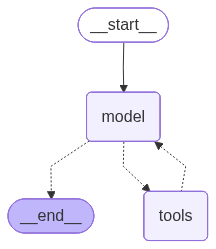

In [31]:
agent

In [32]:
from langchain_classic.agents import AgentExecutor
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)
agent_executor

AgentExecutor(verbose=True, agent=RunnableAgent(runnable=<langgraph.graph.state.CompiledStateGraph object at 0x00000223624F8220>, input_keys_arg=[], return_keys_arg=[], stream_runnable=True), tools=[WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\Lenovo\\OneDrive\\Desktop\\Lanchain_k\\venv\\lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=5, lang='en', load_all_available_meta=False, doc_content_chars_max=250)), ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.arxiv.ArxivError'>, <class 'arxiv.arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.arxiv.HTTPError'>), top_k_results=5, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=250)), StructuredTool(name='retrieve_documents', description='Search documents and return relevant context.', args_schema=<class 'langchain_core.utils.pydantic.

In [33]:
import langchain
import langchain_core

print("LangChain:", langchain.__version__)
print("LangChain Core:", langchain_core.__version__)

LangChain: 1.3.8
LangChain Core: 1.4.6


In [ ]:
print(llm)

metadata={'versions': {'langchain-core': '1.4.6', 'langchain': '1.3.8'}} output_version=None profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True} client=<groq.resources.chat.completions.Completions object at 0x000001B593028EE0> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B593028D30> model_name='llama-3.3-70b-versatile' temperature=1e-08 model_kwargs={} groq_api_key=None groq_api_base=None groq_proxy=None


In [ ]:
llm.bind_tools(tools)

_ChatModelBinding(bound=ChatGroq(metadata={'versions': {'langchain-core': '1.4.6', 'langchain': '1.3.8'}}, output_version=None, profile={'name': 'Compound', 'release_date': '2025-09-04', 'last_updated': '2025-09-04', 'open_weights': False, 'max_input_tokens': 131072, 'max_output_tokens': 8192, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B5D5EB59C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B5D5EB60B0>, model_name='groq/compound', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'wikipedia', 'description': 'A wrapper around Wikipedia. Useful for when

In [37]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Who is Shivaji Maharaj? Use Wikipedia."
            }
        ]
    }
)

print(result["messages"][-1].content)

Shivaji Maharaj, also known as Chhatrapati Shivaji Maharaj, was a Indian ruler and a member of the Bhonsle dynasty. He is considered one of the greatest rulers in Indian history and is revered as a hero in Maharashtra, India. Shivaji was born on February 19, 1630, and died on April 3, 1680. He inherited a fiefdom from his father and went on to establish a vast empire, known as the Maratha Empire, which covered much of western and central India. Shivaji is known for his military prowess, administrative skills, and his efforts to promote Hinduism and the Marathi language. He is also remembered for his bravery and his fight against the Mughal Empire and other Muslim rulers of the time. Shivaji's legacy continues to be celebrated in India, and he is considered a national hero.


In [38]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "attention all you need to give summary of this research paper"
            }
        ]
    }
)

print(result["messages"][-1].content)

c:\Users\Lenovo\OneDrive\Desktop\Lanchain_k\venv\lib\site-packages\wikipedia\wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file c:\Users\Lenovo\OneDrive\Desktop\Lanchain_k\venv\lib\site-packages\wikipedia\wikipedia.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')
c:\Users\Lenovo\OneDrive\Desktop\Lanchain_k\venv\lib\site-packages\wikipedia\wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or 

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01k05x328df29add4b0ej0n3qp` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 93348, Requested 7870. Please try again in 17m32.352s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [40]:
from langchain_classic.agents import initialize_agent,AgentType